### ***Project Title :  Bankruptcy Prediction using Machine Learning***

 ***Step No : 1 Project Overview :*** 

**Project Problem Statement :** 

The objective of this project is to develop a machine learning model that can predict whether a company is financially healthy or at risk of bankruptcy based on its financial attributes such as profitability, liquidity, leverage, and operational efficiency.
Accurately identifying companies that may face financial distress is crucial, as it helps prevent potential losses caused by unpaid debts and poor investment decisions.


**Goal & Objectives :**

The key objectives of this project are:

- To analyze financial data and identify patterns related to company performance  
- To build and train machine learning models for bankruptcy prediction  
- To evaluate model performance using appropriate metrics  
- To help investors and stakeholders make data-driven financial decisions  
- To provide early warning signals for potential financial risks

**Business Impact**

- Helps investors avoid risky investments  
- Supports financial institutions in credit risk assessment  
- Enables early detection of financially distressed companies 

***Step No : 2 Importing Required Libraries :*** 

In [2]:
# Import Required Libraries
# Importing basic libraries for numerical operations and data handling
import numpy as np
import pandas as pd

# Importing visualization libraries to create charts and graphs
import matplotlib.pyplot as plt
import seaborn as sns

# Pickle is used to save the trained model so we can use it later in deployment
import pickle

# train_test_split helps us divide the dataset into training and testing parts
from sklearn.model_selection import train_test_split

# Random Forest is an ensemble machine learning algorithm used for classification
from sklearn.ensemble import RandomForestClassifier

# XGBoost is a powerful boosting algorithm that often performs very well on structured data
from xgboost import XGBClassifier

# Importing evaluation metrics to measure model performance properly
from sklearn.metrics import (
    accuracy_score,          # To check overall prediction accuracy
    classification_report,   # To see precision, recall, and F1-score
    confusion_matrix,        # To understand correct and wrong predictions in detail
    roc_auc_score,           # To measure how well the model separates classes
    roc_curve                # To plot the ROC curve for model evaluation
)


***Step No : 3 Loading Dataset***

In [3]:
# Load dataset
df = pd.read_csv("BANKRUPTCY PREDICTION  -DATASCIENCE DATASET.csv")

# Clean column names (remove extra spaces)
df.columns = df.columns.str.strip()

# Preview data
df


,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Equity to Liability,Bankrupt
0,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,0.780985,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,0.016469,1
1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,0.781506,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,0.020794,1
2,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,0.780284,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,0.016474,1
3,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,0.781241,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,0.023982,1
4,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,0.781550,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,0.035490,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6814,0.493687,0.539468,0.543230,0.604455,0.604462,0.998992,0.797409,0.809331,0.303510,0.781588,...,0.799927,0.000466,0.623620,0.604455,0.840359,0.279606,0.027064,0.566193,0.029890,0
6815,0.475162,0.538269,0.524172,0.598308,0.598308,0.998992,0.797414,0.809327,0.303520,0.781586,...,0.799748,0.001959,0.623931,0.598306,0.840306,0.278132,0.027009,0.566018,0.038284,0
6816,0.472725,0.533744,0.520638,0.610444,0.610213,0.998984,0.797401,0.809317,0.303512,0.781546,...,0.797778,0.002840,0.624156,0.610441,0.840138,0.275789,0.026791,0.565158,0.097649,0
6817,0.506264,0.559911,0.554045,0.607850,0.607850,0.999074,0.797500,0.809399,0.303498,0.781663,...,0.811808,0.002837,0.623957,0.607846,0.841084,0.277547,0.026822,0.565302,0.044009,0


 ***Step 4 : Data Understanding***

In [4]:
# Data Understanding
# Check dataset size (rows, columns)
print("Dataset Shape:", df.shape)

# Get basic info (columns, data types, null values)
print("\nDataset Info:")
df.info()

# View statistical summary of numerical features
print("\nStatistical Summary:")
print(df.describe())

# Check missing values in each column
print("\nMissing Values:")
print(df.isnull().sum())

# Check duplicate rows in dataset
print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (6819, 95)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 95 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   ROA(C) before interest and depreciation before interest  6819 non-null   float64
 1   ROA(A) before interest and % after tax                   6819 non-null   float64
 2   ROA(B) before interest and depreciation after tax        6819 non-null   float64
 3   Operating Gross Margin                                   6819 non-null   float64
 4   Realized Sales Gross Margin                              6819 non-null   float64
 5   Operating Profit Rate                                    6819 non-null   float64
 6   Pre-tax net Interest Rate                                6819 non-null   float64
 7   After-tax net Interest Rate                              6819 non-null   

***Step No : 5 Data Cleaning / Preprocessing***

In [5]:
# Data Cleaning / Preprocessing

# Fill missing values
df = df.fillna(0)

# Remove duplicate rows
df = df.drop_duplicates()

print("Cleaned Dataset Shape:", df.shape)

Cleaned Dataset Shape: (6819, 95)


***Step No : 6 Exploratory Data Analysis (EDA)*** 

##### 6.1: *Univariate Analysis :*
- Target distribution
- Histogram
- Boxplot

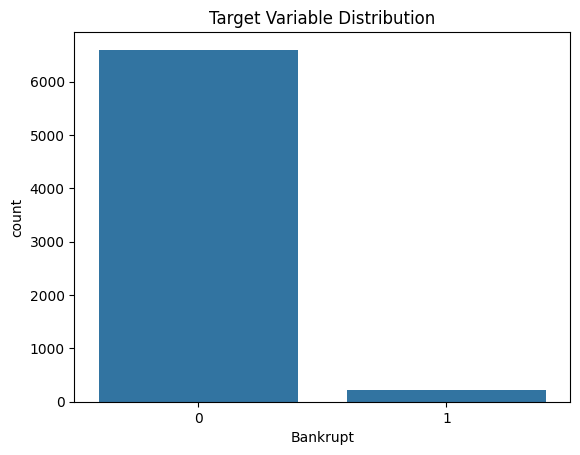

In [6]:
# Target Variable Distribution
# Count of each class
sns.countplot(x='Bankrupt', data=df)
plt.title("Target Variable Distribution")
plt.show()


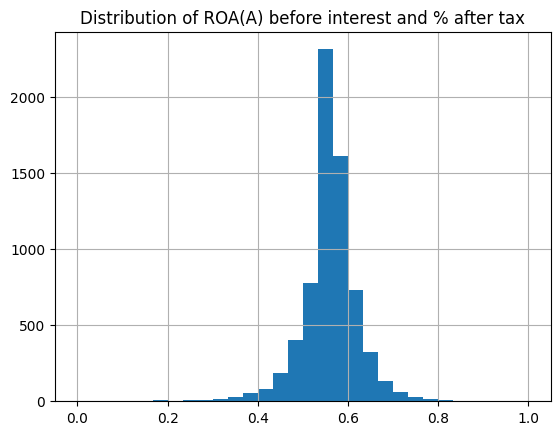

In [7]:
# Numerical Feature Distribution 
# Example Feature 
feature = 'ROA(A) before interest and % after tax'

# Histogram
df[feature].hist(bins=30)
plt.title(f"Distribution of {feature}")
plt.show()

###

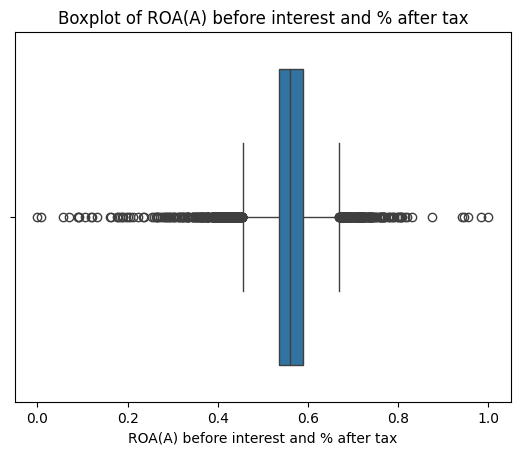

In [8]:
# Using Boxplot for checking Outliers in the dataset 
sns.boxplot(x=df[feature])
plt.title(f"Boxplot of {feature}")
plt.show()

#### 6.2 *Bivariate Analysis :*


- ROA vs Bankruptcy
- Mean comparison
- Correlation with target

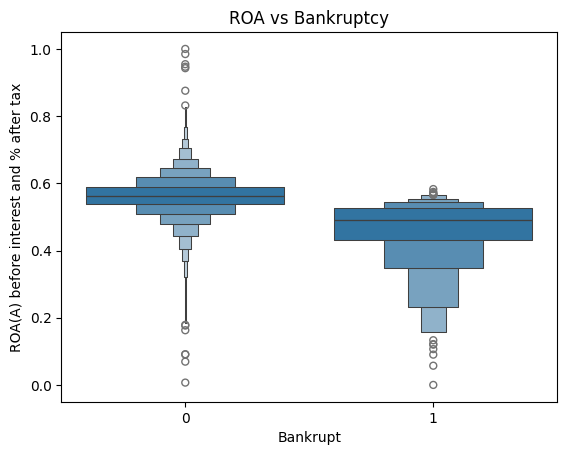

In [9]:
# Compare the distribution of ROA between bankrupt and non-bankrupt companies
sns.boxenplot(x='Bankrupt',y='ROA(A) before interest and % after tax',data=df)
plt.title("ROA vs Bankruptcy")
plt.show()

##### **Mean Comparison :**

In [10]:
# Compute the mean ROA for each bankruptcy group to understand differences in financial performance.
df.groupby("Bankrupt")['ROA(A) before interest and % after tax'].mean()

Bankrupt
0    0.562015
1    0.456947
Name: ROA(A) before interest and % after tax, dtype: float64

In [11]:
# Analyze correlation of all numeric features with the target variable (Bankrupt)
# to identify the most important predictors of bankruptcy
corr = df.corr(numeric_only=True)['Bankrupt'].sort_values(ascending=False)

print("Top Positive Correlation:\n", corr.head(10))
print("Top Negative Correlation:\n", corr.tail(10))


Top Positive Correlation:
 Bankrupt                               1.000000
Debt ratio %                           0.250161
Current Liability to Assets            0.194494
Borrowing dependency                   0.176543
Current Liability to Current Assets    0.171306
Liability to Equity                    0.166812
Current Liabilities/Equity             0.153828
Current Liability to Equity            0.153828
Liability-Assets Flag                  0.139212
Total expense/Assets                   0.139049
Name: Bankrupt, dtype: float64
Top Negative Correlation:
 Working Capital to Total Assets                           -0.193083
Per Share Net profit before tax (Yuan �                   -0.201395
Net profit before tax/Paid-in capital                     -0.207857
Retained Earnings to Total Assets                         -0.217779
Persistent EPS in the Last Four Seasons                   -0.219560
Net worth/Assets                                          -0.250161
ROA(C) before interest and 

#### 6.3*Multivariate Analysis : (Feature vs Feature)*
- Heatmap
- Pairplot

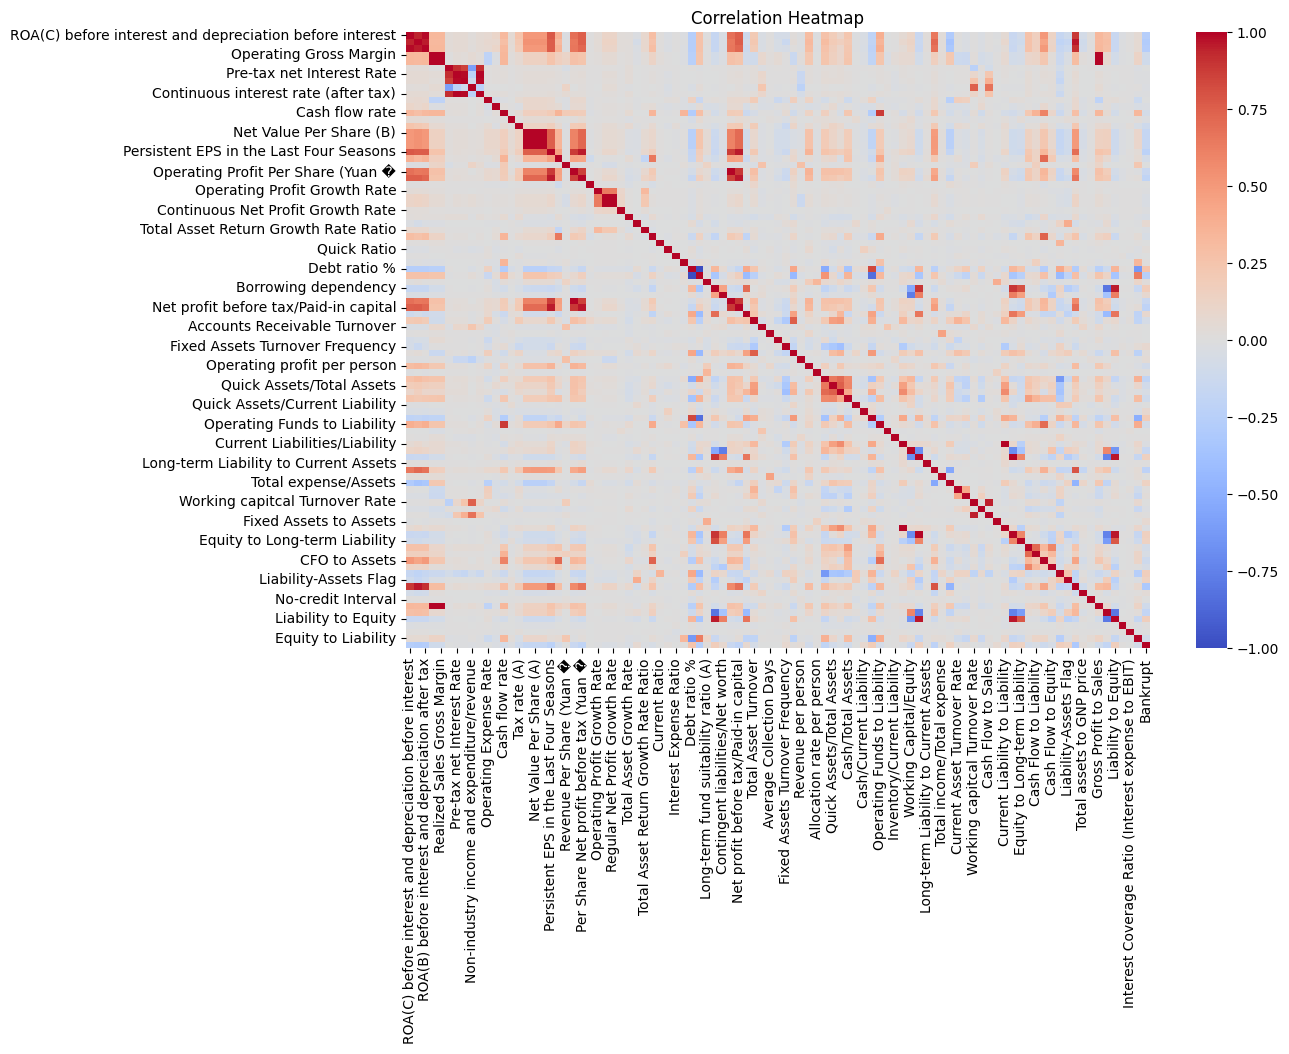

In [12]:
# Visualize correlation between features to detect multicollinearity
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


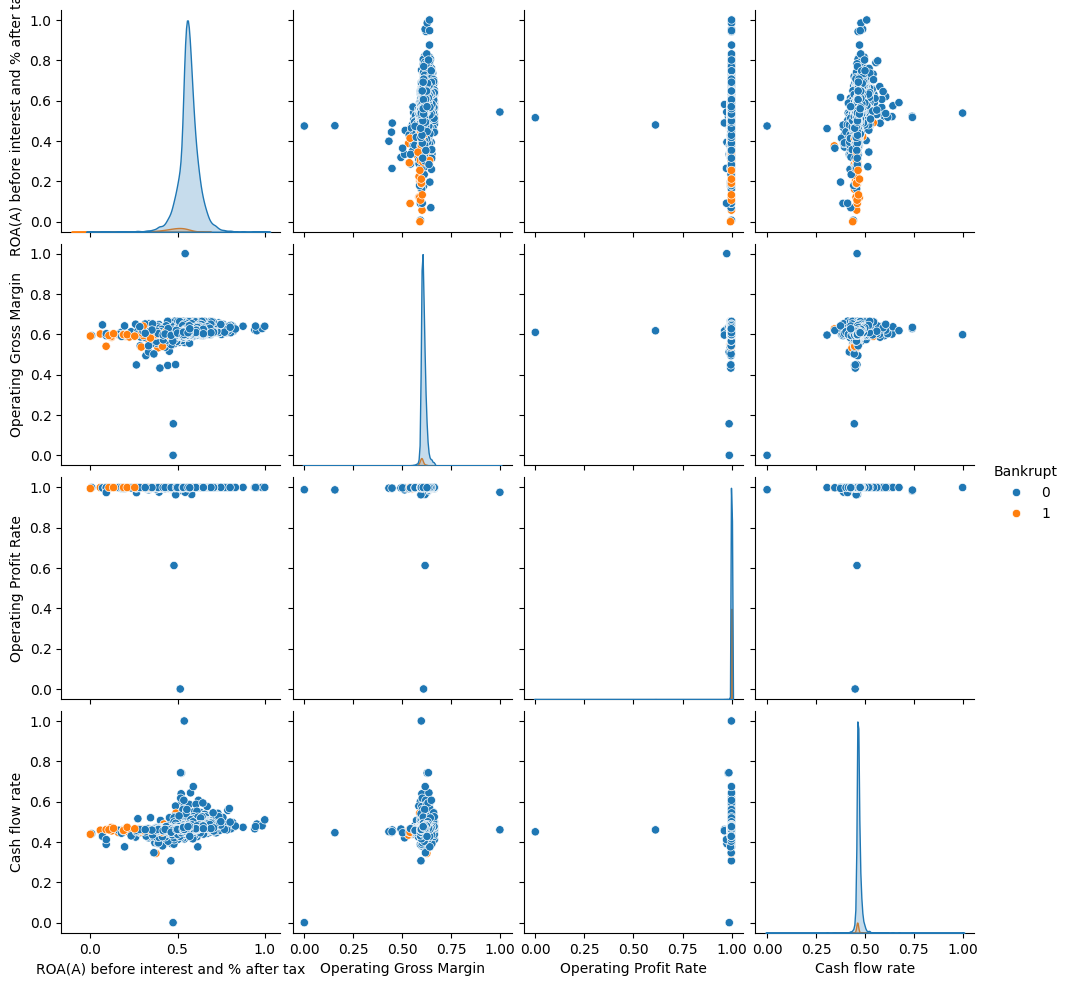

In [13]:
# Visualize pairwise relationships between selected important features and observe patterns by bankruptcy status
selected_features = ['Bankrupt',
                     'ROA(A) before interest and % after tax',
                     'Operating Gross Margin',
                     'Operating Profit Rate',
                     'Cash flow rate']
sns.pairplot(df[selected_features], hue = 'Bankrupt')
plt.show()

***Step No : 7 Feature Engineering*** 

In [14]:
# Feature Engineering
# Handle missing values (safety step)
df = df.fillna(0)

# Separate features and target variable
X = df.drop('Bankrupt', axis=1)
y = df['Bankrupt']

# Create new financial ratio features to improve model performance

# Profitability relative to debt
X['Profit_to_Debt'] = X['Net Income to Total Assets'] / (X['Debt ratio %'] + 1e-5)

# Operational efficiency combined with company value
X['Asset_Turnover_x_NetWorth'] = X['Total Asset Turnover'] * X['Net Value Per Share (B)']

# Liquidity relative to operating expenses
X['Liquidity_to_Expense'] = X['Current Ratio'] / (X['Operating Expense Rate'] + 1e-5)

# Display newly created features
print("Feature Engineering Done Successfully ")
print("Original shape:", df.shape)
print("Feature set shape:", X.shape)

print("\nNew Features Preview:")
print(X[['Profit_to_Debt', 'Asset_Turnover_x_NetWorth', 'Liquidity_to_Expense']].head())

Feature Engineering Done Successfully 
Original shape: (6819, 95)
Feature set shape: (6819, 97)

New Features Preview:
   Profit_to_Debt  Asset_Turnover_x_NetWorth  Liquidity_to_Expense
0        3.453241                   0.012865          1.664711e+01
1        4.645798                   0.011749          2.006840e+01
2        3.732884                   0.002667          4.689617e+01
3        4.882361                   0.013870          3.557634e+01
4        7.463602                   0.029382          7.633011e-13


***Step No : 8 Train - Test Split*** 

In [15]:
# Train-Test Split
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,          # 20% data for testing
    random_state=42,        # ensures reproducibility
    stratify=y              # maintains class balance (important for imbalanced data)
)

# Display shapes of split data
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (5455, 97)
Testing Data Shape: (1364, 97)


#### 8A. Model Improvement using SMOTE

In [16]:
# Apply SMOTE to balance the minority class in training data
# This helps the model learn bankrupt cases better

# model Improvement using SMOTE 
from imblearn.over_sampling import SMOTE

# Apply SMOTE only on training data 
smote = SMOTE(random_state = 42 )


X_train_smote , y_train_smote = smote.fit_resample(X_train , y_train)

print("Before SMOTE:")
print(y_train.value_counts())
print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Bankrupt
0    5279
1     176
Name: count, dtype: int64

After SMOTE:
Bankrupt
0    5279
1    5279
Name: count, dtype: int64


#### *8B. Train XGBoost on SMOTE Data*

In [17]:

# Train XGBoost on SMOTE Data


xgb_model_smote = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_model_smote.fit(X_train_smote, y_train_smote)

print("XGBoost model trained on SMOTE data successfully ✅")

XGBoost model trained on SMOTE data successfully ✅


***Step No : 9 Model Training*** 

In [18]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Random Forest Model 
rf_model = RandomForestClassifier(
    n_estimators= 200,
    random_state=42,
    class_weight= 'balanced'
)

# XGBoost Model
xgb_model = XGBClassifier(
    n_estimators = 200,
    max_depth = 6,
    learning_rate = 0.1,
    random_state = 42,
    eval_metric = 'logloss'
)

# Train both models 
rf_model.fit(X_train , y_train)
xgb_model.fit(X_train, y_train)

print("Random Forest and XGBoost trained successfully")

Random Forest and XGBoost trained successfully


***Step No : 10 Model Predictions*** 

In [19]:
# Predictions
# Predictions from original models
rf_pred = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

# Final prediction from SMOTE-trained XGBoost model
y_pred = xgb_model_smote.predict(X_test)

print("Predictions generated successfully ✅")
print("Final selected model: XGBoost with SMOTE ✅")

Predictions generated successfully ✅
Final selected model: XGBoost with SMOTE ✅


***Step No : 11 Probability Predictions*** 

In [20]:
# Probability Prediction

xgb_probs = xgb_model_smote.predict_proba(X_test)[:, 1]

print("Probability predictions generated successfully ✅")

Probability predictions generated successfully ✅


 ***Step 12. Model Evaluation (Before SMOTE)***

In [21]:
# Model Evaluation (Before SMOTE)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("======== Random Forest ========")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("\nClassification Report:\n", classification_report(y_test, rf_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, rf_pred))

print("\n======= XGBoost ========")
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("\nClassification Report:\n", classification_report(y_test, xgb_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, xgb_pred))

======== Random Forest ========
Accuracy: 0.9714076246334311

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99      1320
           1       0.73      0.18      0.29        44

    accuracy                           0.97      1364
   macro avg       0.85      0.59      0.64      1364
weighted avg       0.97      0.97      0.96      1364


Confusion Matrix:
 [[1317    3]
 [  36    8]]

======= XGBoost ========
Accuracy: 0.9721407624633431

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99      1320
           1       0.62      0.36      0.46        44

    accuracy                           0.97      1364
   macro avg       0.80      0.68      0.72      1364
weighted avg       0.97      0.97      0.97      1364


Confusion Matrix:
 [[1310   10]
 [  28   16]]


#### *12A. Model Comparison Table*

In [22]:
# Model Comparison Table
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    'Precision': [
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],
    'Recall': [
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],
    'F1-Score': [
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ]
})

print("Model Comparison Table:")
print(comparison_df)

Model Comparison Table:
           Model  Accuracy  Precision    Recall  F1-Score
0  Random Forest  0.971408   0.727273  0.181818  0.290909
1        XGBoost  0.972141   0.615385  0.363636  0.457143


#### *12B. Final Model Evaluation (After SMOTE)*

In [23]:
# Final Model Evaluation (After SMOTE)
print("======= XGBoost with SMOTE ========")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

======= XGBoost with SMOTE ========
Accuracy: 0.968475073313783

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      1320
           1       0.51      0.52      0.52        44

    accuracy                           0.97      1364
   macro avg       0.75      0.75      0.75      1364
weighted avg       0.97      0.97      0.97      1364


Confusion Matrix:
 [[1298   22]
 [  21   23]]


#### *12C. Before vs After SMOTE Comparison*

In [24]:
# Before vs After SMOTE Comparison
smote_comparison_df = pd.DataFrame({
    'Version': ['Before SMOTE', 'After SMOTE'],
    'Accuracy': [
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, y_pred)
    ],
    'Precision': [
        precision_score(y_test, xgb_pred),
        precision_score(y_test, y_pred)
    ],
    'Recall': [
        recall_score(y_test, xgb_pred),
        recall_score(y_test, y_pred)
    ],
    'F1-Score': [
        f1_score(y_test, xgb_pred),
        f1_score(y_test, y_pred)
    ]
})

print("Before Vs After SMOTE Comparison Table:")
print(smote_comparison_df)

Before Vs After SMOTE Comparison Table:
        Version  Accuracy  Precision    Recall  F1-Score
0  Before SMOTE  0.972141   0.615385  0.363636  0.457143
1   After SMOTE  0.968475   0.511111  0.522727  0.516854


***Step No: 13. ROC-AUC Score :***

In [25]:
# ROC-AUC Score
from sklearn.metrics import roc_auc_score

roc_score = roc_auc_score(y_test, xgb_probs)

print("ROC AUC Score after SMOTE:", roc_score)

ROC AUC Score after SMOTE: 0.9585915977961433


#### *13A. ROC Curve*

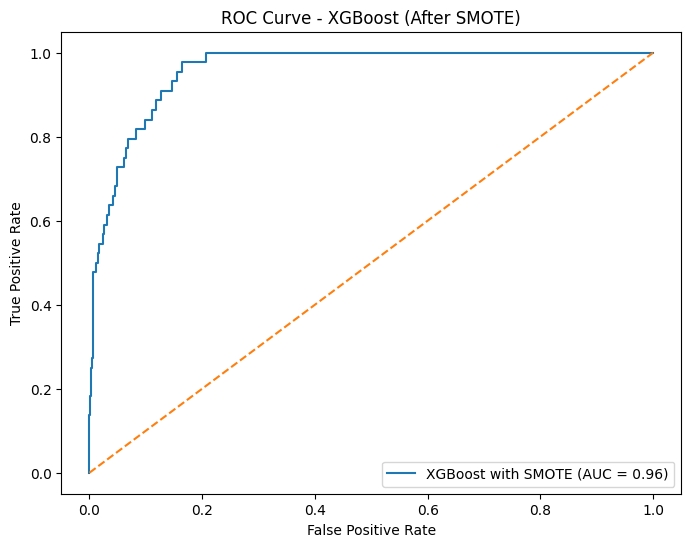

In [26]:
# ROC Curve
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, xgb_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"XGBoost with SMOTE (AUC = {roc_score:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost (After SMOTE)")
plt.legend()
plt.show()

***Step 14 : Feature Importance (FINAL MODEL)***

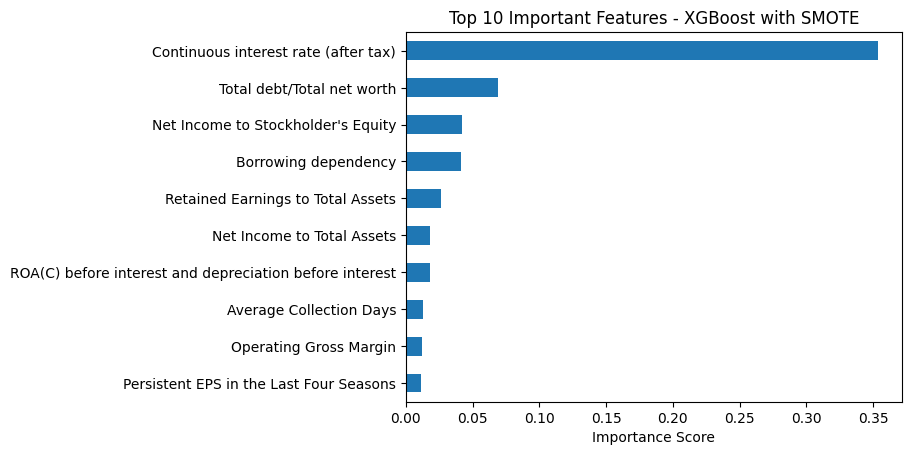

In [27]:
# Feature Importance
feature_importance = pd.Series(
    xgb_model_smote.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance.head(10).sort_values().plot(kind='barh')

plt.title("Top 10 Important Features - XGBoost with SMOTE")
plt.xlabel("Importance Score")
plt.show()

***Step 15 : Create dataset for Power BI Dashboard***

In [28]:
# Create dataset for Power BI Dashboard

# Copy test dataset (features) to preserve original data
final_df = X_test.copy()

# Add actual target values (ground truth)
final_df['Actual'] = y_test.values

# Add model predictions (predicted class: 0 or 1)
final_df['Predicted'] = y_pred

# Add prediction probabilities (used for risk analysis & ROC-AUC)
final_df['Probability'] = xgb_probs

# Export final dataset to CSV for Power BI dashboard visualization
final_df.to_csv("dashboard_data.csv", index=False)

print("Dashboard data saved successfully ✅")

Dashboard data saved successfully ✅


 **Step 16 : Streamlit Demo Model (Deployment Only)**

#### *16- A : Select top important features for lightweight demo model*

In [29]:
# Select top important features for lightweight demo model
import pandas as pd

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model_smote.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(10))

# Pick top 5 features for app input
selected_features = importance_df['Feature'].head(5).tolist()
print("Selected top 5 features:", selected_features)

# Create reduced dataset for demo model
X_selected = X[selected_features].copy()
y_selected = y.copy()

                                              Feature  Importance
9                Continuous interest rate (after tax)    0.353844
35                         Total debt/Total net worth    0.069311
89                 Net Income to Stockholder's Equity    0.042400
39                               Borrowing dependency    0.041503
67                  Retained Earnings to Total Assets    0.026185
85                         Net Income to Total Assets    0.018080
0   ROA(C) before interest and depreciation before...    0.017897
46                            Average Collection Days    0.013154
3                              Operating Gross Margin    0.012208
18            Persistent EPS in the Last Four Seasons    0.011212
Selected top 5 features: ['Continuous interest rate (after tax)', 'Total debt/Total net worth', "Net Income to Stockholder's Equity", 'Borrowing dependency', 'Retained Earnings to Total Assets']


#### *16-B : Train-Test Split :* 

In [30]:
# Split demo dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train_demo, X_test_demo, y_train_demo, y_test_demo = train_test_split(
    X_selected, y_selected,
    test_size=0.2,
    random_state=42,
    stratify=y_selected
)

#### 16-C : Apply SMOTE

In [31]:
# Balance the demo training data using SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_demo_smote, y_train_demo_smote = smote.fit_resample(X_train_demo, y_train_demo)

print("Before SMOTE:")
print(y_train_demo.value_counts())

print("\nAfter SMOTE:")
print(y_train_demo_smote.value_counts())

Before SMOTE:
Bankrupt
0    5279
1     176
Name: count, dtype: int64

After SMOTE:
Bankrupt
0    5279
1    5279
Name: count, dtype: int64


#### 16-D :Train Demo Model

In [32]:
# Train a lightweight XGBoost model for deployment
from xgboost import XGBClassifier

demo_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

demo_model.fit(X_train_demo_smote, y_train_demo_smote)
print("Demo model trained successfully ")

Demo model trained successfully 


#### 16-E Evaluate Demo Model

In [33]:
# Check performance of demo model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_demo = demo_model.predict(X_test_demo)

print("Accuracy:", accuracy_score(y_test_demo, y_pred_demo))
print("\nClassification Report:\n", classification_report(y_test_demo, y_pred_demo))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_demo, y_pred_demo))

Accuracy: 0.908357771260997

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.92      0.95      1320
           1       0.20      0.61      0.30        44

    accuracy                           0.91      1364
   macro avg       0.59      0.77      0.63      1364
weighted avg       0.96      0.91      0.93      1364


Confusion Matrix:
 [[1212  108]
 [  17   27]]


#### 16-F : Save Files

In [34]:
# Save model and selected features for Streamlit app
import pickle

pickle.dump(demo_model, open("streamlit_model.pkl", "wb"))
pickle.dump(selected_features, open("streamlit_features.pkl", "wb"))

print("Streamlit demo files saved successfully ")

Streamlit demo files saved successfully 


#### 16-G : Streamlit App

In [35]:
# Build Streamlit UI for prediction
import streamlit as st
import pickle
import numpy as np

# Load saved model and feature list
model = pickle.load(open("streamlit_model.pkl", "rb"))
selected_features = pickle.load(open("streamlit_features.pkl", "rb"))

st.title("Bankruptcy Prediction App")
st.write("Enter the financial values to predict bankruptcy risk.")

# Take user input for each feature
user_inputs = []

for feature in selected_features:
    value = st.number_input(feature, value=0.0)
    user_inputs.append(value)

# Convert input into model format
inputs = np.array([user_inputs])

# Predict on button click
if st.button("Predict"):
    prediction = model.predict(inputs)
    probability = model.predict_proba(inputs)[0][1]

    st.write(f"Bankruptcy Risk Score: {probability:.2%}")

    # Display result based on prediction
    if prediction[0] == 1:
        st.error("⚠️ High Risk of Bankruptcy")
    else:
        st.success(" Company is Financially Healthy")

2026-04-04 17:19:45.993 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-04 17:19:47.292 
  command:

    streamlit run C:\Users\sagar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-04-04 17:19:47.292 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-04 17:19:47.292 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-04 17:19:47.292 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-04 17:19:47.300 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-04 17:19:47.303 Thread 'MainThread': missing ScriptRunContext! This w

***To run the final project correctly, the reviewer must open the Bankruptcy-Prediction-App folder and execute app.py using Streamlit from that same directory***

#### ***Note:***
- The final deployment file for this project is app.py.
- To run the Streamlit application, open terminal inside the
- Bankruptcy-Prediction-App folder and execute:
- python -m streamlit run app.py

#### ***Project Conclusion:***

- This project successfully demonstrates how machine learning can be used to predict whether a company is financially healthy or at risk of bankruptcy based on financial indicators.

- I followed a complete end-to-end pipeline, starting from data understanding, preprocessing, exploratory data analysis, and feature engineering to model building, evaluation, and deployment.

- I trained and compared two machine learning models, Random Forest and XGBoost. Since the dataset was imbalanced, I applied SMOTE to improve the model’s ability to identify bankrupt companies more effectively. After improvement, the XGBoost model with SMOTE delivered better performance and was selected as the final model.

- To make the project more practical and business-friendly, I used prediction probabilities for risk interpretation. I also created a Power BI dashboard dataset for visualization and developed a lightweight Streamlit application to allow real-time bankruptcy prediction using the most important financial features.

- Overall, this project highlights how machine learning can support investors, analysts, and financial institutions in identifying financially risky companies early and making more informed decisions.